In [85]:
import pandas as pd

In [86]:
df=pd.read_csv('/content/heart.csv')

In [87]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [88]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [89]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [91]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# checking the skewness

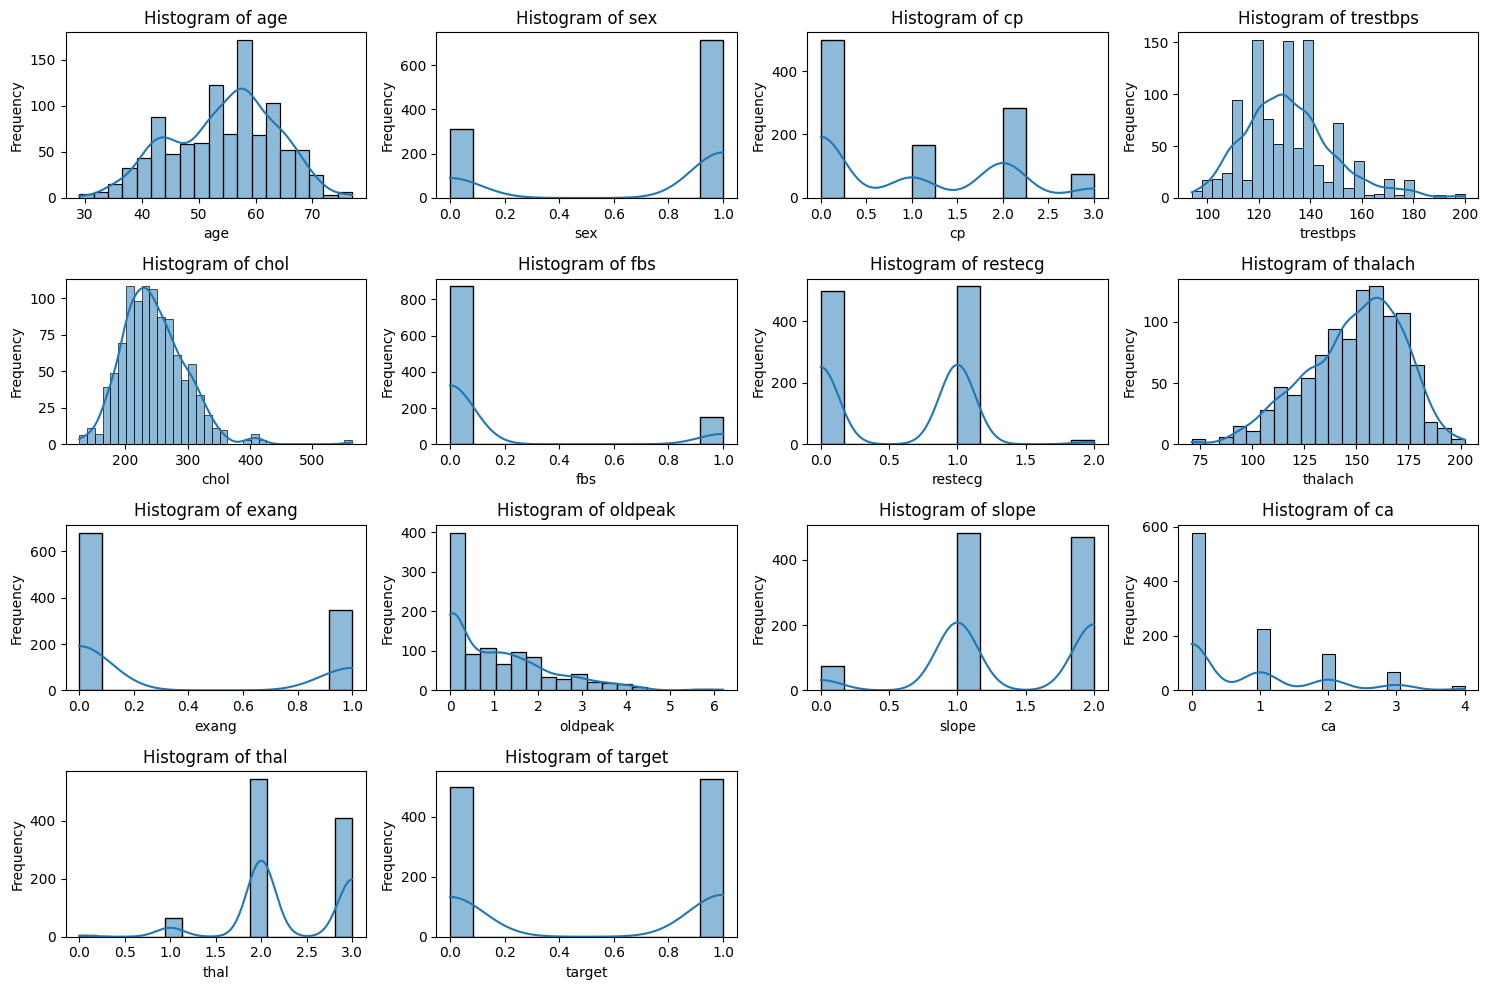

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 10))
for i,col in enumerate (num_cols,1):
    plt.subplot(4,4,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [93]:
df.nunique().sort_values()

,0
sex,2
fbs,2
target,2
exang,2
restecg,3
slope,3
thal,4
cp,4
ca,5
oldpeak,40


In [94]:
import numpy as np

df['chol'] = np.log1p(df['chol'])
df['oldpeak'] = np.log1p(df['oldpeak'])
df['trestbps'] = np.log1p(df['trestbps'])

# checking the outliers

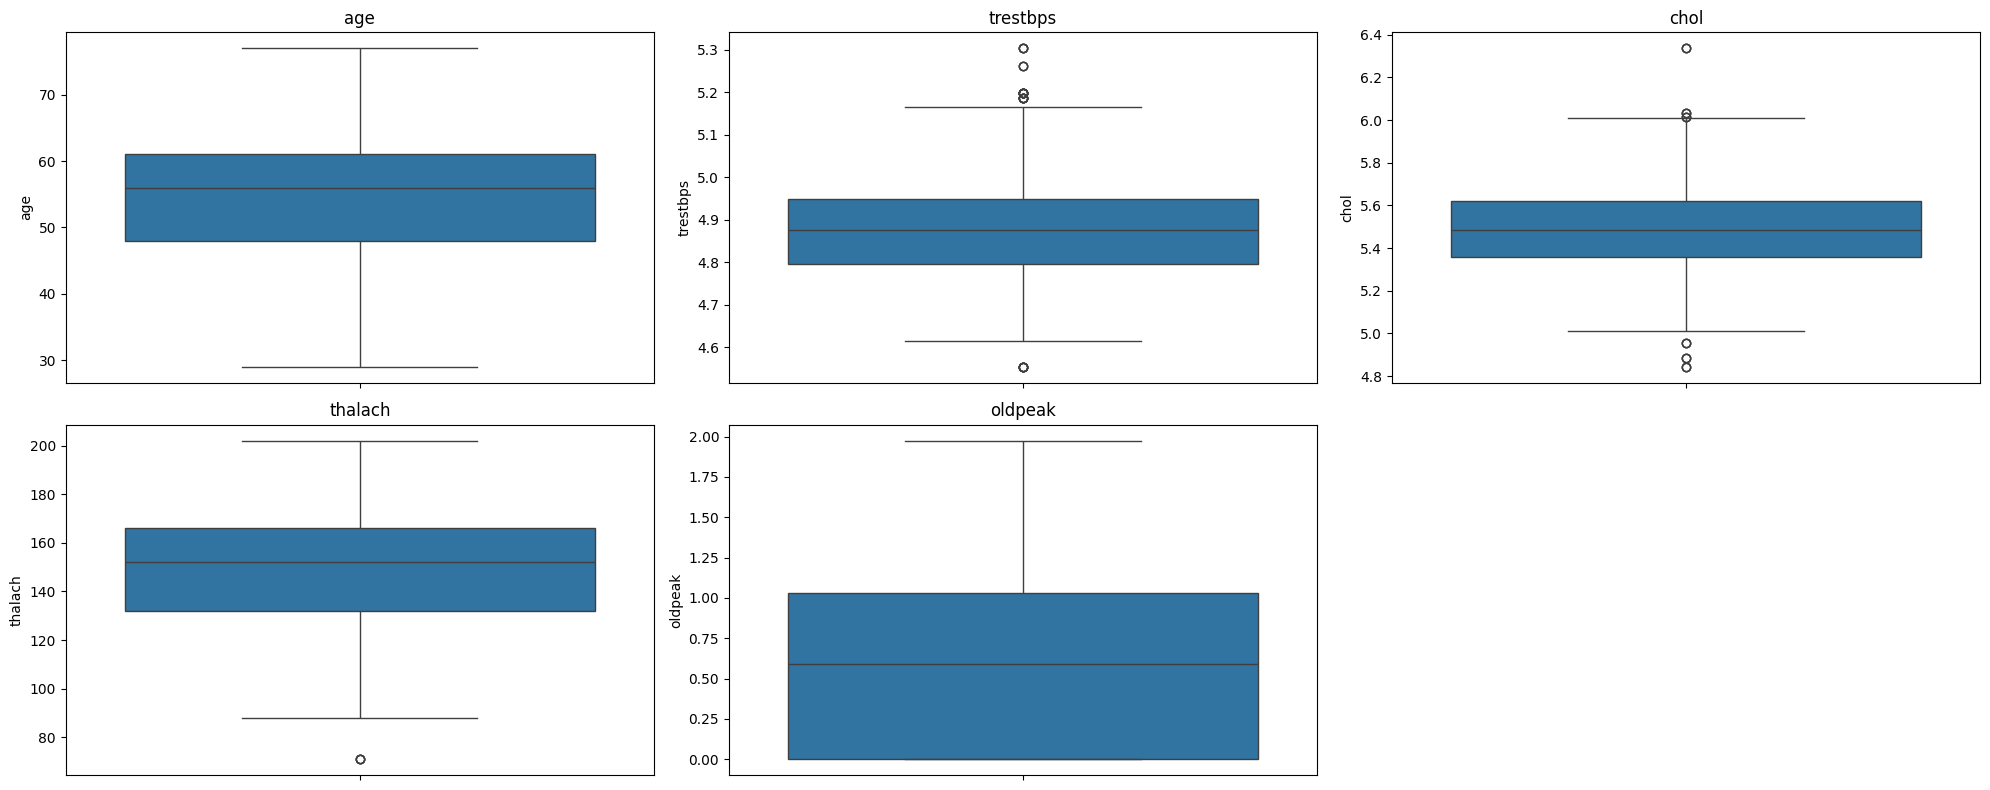

In [95]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(20,8))
for i,col in enumerate (continuous_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Fit the decission tree model

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,

)
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)


# feature importance

In [97]:
import pandas as pd

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(dt_importance)

     Feature  Importance
2         cp    0.274524
12      thal    0.147141
11        ca    0.118901
4       chol    0.096328
9    oldpeak    0.094503
0        age    0.055125
7    thalach    0.053874
3   trestbps    0.047069
10     slope    0.043984
1        sex    0.026434
8      exang    0.018866
6    restecg    0.014881
5        fbs    0.008371


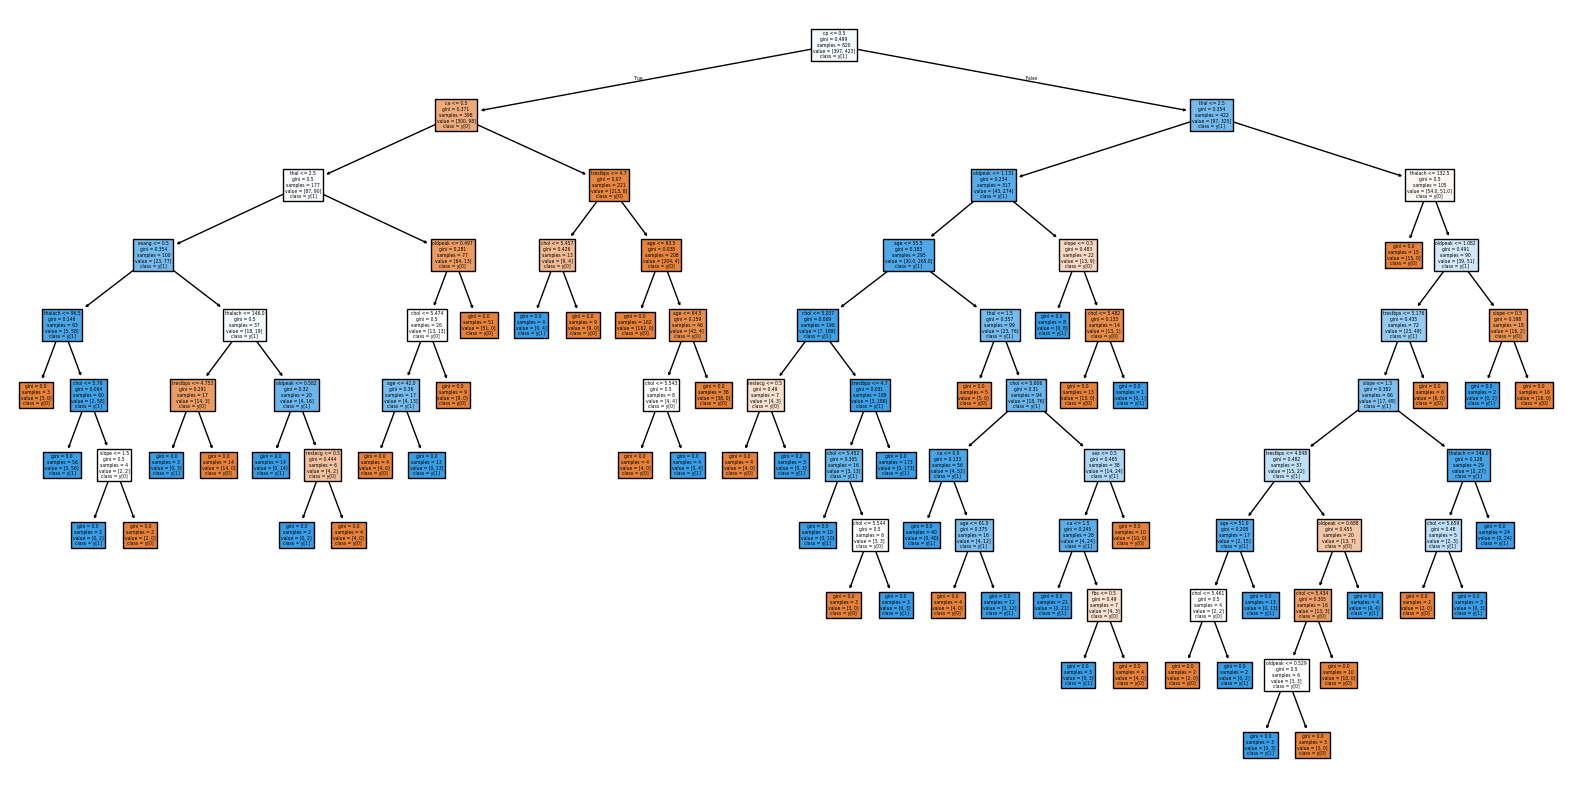

In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.show()

# overfitting analisis

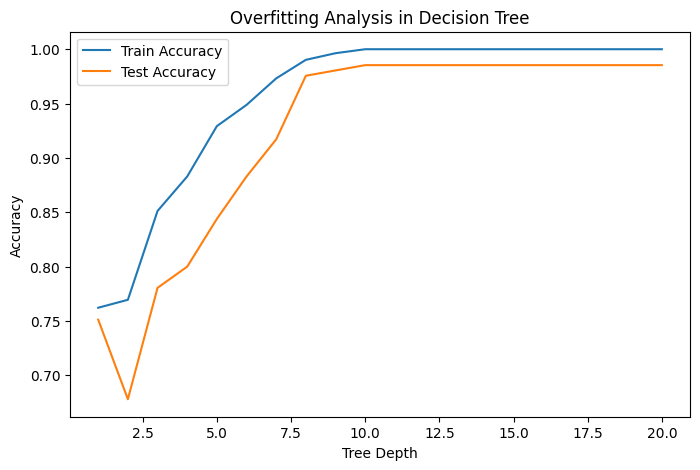

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []
depths = range(1, 21)

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))


plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis in Decision Tree")
plt.legend()
plt.show()

# fit the randomforestclassifier model

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_tree = dt_model.predict(X_test)  # your decision tree

In [102]:
import pandas as pd

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


# compare the accuracy

In [101]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, y_pred_tree)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366


# Evaluate using cross-validation.

In [103]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Decision Tree CV Accuracy:", dt_scores.mean())
print("Scores:", dt_scores)


Decision Tree CV Accuracy: 1.0
Scores: [1. 1. 1. 1. 1.]


In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Accuracy:", rf_scores.mean())
print("Scores:", rf_scores)

Random Forest CV Accuracy: 0.9970731707317073
Scores: [1.         1.         1.         1.         0.98536585]


In [105]:
print("Decision Tree Mean CV Accuracy:", dt_scores.mean())
print("Random Forest Mean CV Accuracy:", rf_scores.mean())

Decision Tree Mean CV Accuracy: 1.0
Random Forest Mean CV Accuracy: 0.9970731707317073
